# DeepLabV3+ Fine-Tuning: AI Inpainting Detection

**Task:** Binary semantic segmentation — detect AI-inpainted regions in images.
- **Class 0:** Real / Not inpainted (black in mask)
- **Class 1:** AI inpainted region (white in mask)

**Dataset layout:**
```
sd2-fr/{training,validation,testing}/<category>/  ← RGB images  
masks-sd2/{training,validation,testing}/<category>/  ← Binary masks (*_mask_512.png)
```

**Image ↔ Mask pairing rule:**  
`<id>_mask_random.png_sd2-512_0.png` and `..._1.png`  →  `<id>_mask_512.png`


## 0. Install Dependencies

In [ ]:
# # Run once if needed
# !pip install torch torchvision tqdm matplotlib segmentation-models-pytorch
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [15]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
12.1
NVIDIA H100 NVL


## 1. Imports & Configuration

In [16]:
import os
import json
import re
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms.functional as TF

# segmentation_models_pytorch gives us a clean DeepLabV3+ with flexible backbones
import segmentation_models_pytorch as smp

# Locate the repo root (the folder containing authentilens/) so paths work from any cwd.
import sys
REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'authentilens').is_dir()), None)
assert REPO_ROOT is not None, 'Run this notebook from inside the AuthentiLens repository.'
sys.path.insert(0, str(REPO_ROOT))
from authentilens.paths import DATA_DIR, SEGMENTATION_CKPT_DIR  # data/ and checkpoints/segmentation/

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU             : NVIDIA H100 NVL


In [ ]:
CONFIG = {
    # ---- paths --------------------------------------------------------
    # Each entry is one (images_root, masks_root) dataset pair.
    # They are zipped together, so order must match.
    # SD2  images are 512px  -> masks named  <id>_mask_512.png
    # SDXL images are 1024px -> masks named  <id>_mask_1024.png
    # build_pairs() auto-detects the correct mask suffix per dataset.
    'images_root'     : [str(DATA_DIR / 'sd2-fr'),    str(DATA_DIR / 'sdxl-fr')   ],
    'masks_root'      : [str(DATA_DIR / 'masks-sd2'), str(DATA_DIR / 'masks-sdxl')],
    'save_dir'        : str(SEGMENTATION_CKPT_DIR / 'deeplabv3plus'),
 
    # ---- model --------------------------------------------------------
    'encoder'         : 'resnet50',     # swap to 'resnet101' for heavier backbone
    'encoder_weights' : 'imagenet',
    'num_classes'     : 1,              # 1 output channel -> binary with BCE loss
    # Dropout in the decoder head -- primary knob against overfitting.
    # 0.3 is a good starting point; raise to 0.5 if still overfitting.
    'decoder_dropout' : 0.3,
 
    # ---- training -----------------------------------------------------
    'image_size'      : 512,
 
    # H100 has 80 GB HBM3 -- push batch size hard.
    # 512px images: start at 32, monitor GPU memory with `nvidia-smi`.
    # If OOM, drop to 24 or 16.
    'batch_size'      : 32,
 
    'epochs'          : 30,
    'lr'              : 1e-4,           # decoder/head lr; encoder gets lr * 0.1
    # Higher weight_decay = stronger L2 regularisation = less overfitting.
    # Was 1e-4, bumped to 1e-3.

    'weight_decay'    : 1e-3,
 
    # H100 has 132 SM cores -- saturate the data pipeline.
    # Rule of thumb: 4x number of GPUs, capped at logical CPU count.
    # 16 workers keeps the H100 fed without thrashing the CPU.
    'num_workers'     : 16,
 
    # persistent_workers keeps worker processes alive between epochs,
    # saving the fork/init overhead (~5-10s per epoch on large datasets).
    'persistent_workers': True,
 
    # prefetch_factor: each worker pre-loads this many batches ahead.
    # 4 means 16 workers x 4 = 64 batches always ready in shared memory.
    'prefetch_factor' : 4,
 
    'use_amp'         : True,           # BF16 AMP on H100 is essentially free
    'seed'            : 42,
 
    # ---- gradient clipping --------------------------------------------
    # Clips gradient norm to prevent occasional large updates from
    # destabilising training. 1.0 is conservative; safe default.
    'grad_clip'       : 1.0,
 
    # ---- early stopping -----------------------------------------------
    # Stop training if val IoU does not improve for this many epochs.
    # Avoids wasting compute and prevents overfitting to the training set.
    'early_stop_patience': 7,
 
    # ---- loss ---------------------------------------------------------
    # pos_weight : BCE class-imbalance weight; raise if inpainted region is small
    # loss_alpha : weight on BCE term          (must sum with beta to <= 1.0)
    # loss_beta  : weight on Focal term        (set 0.0 to disable Focal entirely)
    # focal_gamma: Focal focusing exponent     (0=plain BCE, 2=standard Focal)
    #   gamma=2 concentrates gradient on hard boundary pixels where
    #   model is uncertain -- very useful for manipulation detection.
    'pos_weight'      : 3.0,
    'loss_alpha'      : 0.4,   # BCE
    'loss_beta'       : 0.2,   # Focal  (remainder 0.4 goes to Dice)
    'focal_gamma'     : 2.0,
 
    # ---- augmentation strength ----------------------------------------
    # Controls how aggressively training images are augmented.
    # Higher = more regularisation = less overfitting, but too high hurts learning.
    # 'light' / 'medium' / 'heavy'
    'aug_strength'    : 'medium',
}
 
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['seed'])
 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device          : {DEVICE}")

Device          : cuda


## 2. Dataset Builder

**Pairing logic:**
- SD2 image filename: `<id>_mask_random.png_sd2-512_0.png`
- Corresponding mask : `<id>_mask_512.png`  (in the matching category folder under `masks-sd2`)
- Both `_0` and `_1` variants map to the **same** mask.

In [18]:
def extract_id(filename: str):
    """
    Pull the numeric COCO image-id from an SD2/SDXL filename.
    '104669_mask_random.png_sd2-512_0.png'  -> '104669'
    '104669_mask_random.png_sdxl-1024_0.png' -> '104669'
    """
    m = re.match(r'^(\d+)_', filename)
    return m.group(1) if m else None
 
 
def infer_mask_suffix(masks_root: str) -> str:
    """
    Peek at the first mask file found under masks_root to detect whether
    this dataset uses _mask_512.png (SD2) or _mask_1024.png (SDXL).
    Falls back to '_mask_512.png' if nothing is found.
    """
    for p in Path(masks_root).rglob('*.png'):
        name = p.name
        # match <id>_mask_<size>.png  (not the random variant)
        m = re.match(r'^\d+_mask_(\d+)\.png$', name)
        if m:
            return f"_mask_{m.group(1)}.png"
    return '_mask_512.png'   # safe default
 
 
def build_pairs(split: str, images_root: str, masks_root: str):
    """
    Walk every category folder for the given split and collect
    (image_path, mask_path) pairs. Both _0 and _1 image variants
    resolve to the same tight mask (<id>_mask_<size>.png).
 
    The mask filename suffix (_mask_512.png vs _mask_1024.png) is
    inferred automatically from the contents of masks_root.
    """
    img_root    = Path(images_root) / split
    mask_root   = Path(masks_root)  / split
    mask_suffix = infer_mask_suffix(masks_root)   # e.g. '_mask_512.png'
 
    if not img_root.exists():
        raise FileNotFoundError(f"Images split folder not found: {img_root}")
    if not mask_root.exists():
        raise FileNotFoundError(f"Masks split folder not found:  {mask_root}")
 
    pairs, missing = [], []
 
    for category_dir in sorted(img_root.iterdir()):
        if not category_dir.is_dir():
            continue
        mask_cat_dir = mask_root / category_dir.name
 
        for img_path in sorted(category_dir.glob('*.png')):
            img_id = extract_id(img_path.name)
            if img_id is None:
                continue
            mask_path = mask_cat_dir / f"{img_id}{mask_suffix}"
            if mask_path.exists():
                pairs.append((img_path, mask_path))
            else:
                missing.append(str(mask_path))
 
    if missing:
        print(f"  [{split}|{Path(images_root).name}] WARNING: {len(missing)} masks not found "
              f"(expected suffix: {mask_suffix}, first 5 shown):")
        for p in missing[:5]:
            print(f"    {p}")
 
    print(f"  [{split}|{Path(images_root).name}] {len(pairs):,} pairs  "
          f"(mask suffix: {mask_suffix})")
    return pairs
 
 
def build_all_pairs(split: str, config: dict) -> list:
    """
    Merge pairs from every (images_root, masks_root) dataset listed in CONFIG.
    CONFIG['images_root'] and CONFIG['masks_root'] may be a single string
    or a list of strings — both are handled.
    """
    img_roots  = config['images_root']
    mask_roots = config['masks_root']
 
    # normalise to lists so single-string configs still work
    if isinstance(img_roots, str):
        img_roots = [img_roots]
    if isinstance(mask_roots, str):
        mask_roots = [mask_roots]
 
    if len(img_roots) != len(mask_roots):
        raise ValueError(
            f"images_root has {len(img_roots)} entries but "
            f"masks_root has {len(mask_roots)} — they must match."
        )
 
    all_pairs = []
    for img_r, mask_r in zip(img_roots, mask_roots):
        all_pairs.extend(build_pairs(split, img_r, mask_r))
 
    print(f"  [{split}] TOTAL: {len(all_pairs):,} pairs across {len(img_roots)} dataset(s)\n")
    return all_pairs
 
 
# Run a quick path sanity-check on import
print("\nVerifying dataset paths...")
for _split in ('training', 'validation', 'testing'):
    _pairs = build_all_pairs(_split, CONFIG)
    if _pairs:
        _ip, _mp = _pairs[0]
        print(f"    sample  image : {_ip.name}")
        print(f"    sample  mask  : {_mp.name}")
print()


Verifying dataset paths...
  [training|sd2-fr] 7,320 pairs  (mask suffix: _mask_512.png)
  [training|sdxl-fr] 7,320 pairs  (mask suffix: _mask_1024.png)
  [training] TOTAL: 14,640 pairs across 2 dataset(s)

    sample  image : 110999_mask_random.png_sd2-512_0.png
    sample  mask  : 110999_mask_512.png
  [validation|sd2-fr] 1,023 pairs  (mask suffix: _mask_512.png)
  [validation|sdxl-fr] 1,023 pairs  (mask suffix: _mask_1024.png)
  [validation] TOTAL: 2,046 pairs across 2 dataset(s)

    sample  image : 109118_mask_random.png_sd2-512_0.png
    sample  mask  : 109118_mask_512.png
  [testing|sd2-fr] 1,029 pairs  (mask suffix: _mask_512.png)
  [testing|sdxl-fr] 1,029 pairs  (mask suffix: _mask_1024.png)
  [testing] TOTAL: 2,058 pairs across 2 dataset(s)

    sample  image : 134886_mask_random.png_sd2-512_0.png
    sample  mask  : 134886_mask_512.png



## 3. Dataset & DataLoader

In [19]:
# ImageNet normalisation — required because the encoder was pretrained on ImageNet
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
 
 
class InpaintingSegDataset(Dataset):
    """
    Binary segmentation dataset.
 
    Returns:
        image  : float32 tensor [3, H, W] normalised to ImageNet stats
        mask   : float32 tensor [1, H, W] with values in {0.0, 1.0}
                 0 = real/not-inpainted,  1 = AI-inpainted
    """
 
    def __init__(self, pairs: list, image_size: int, mode: str = 'train'):
        self.pairs      = pairs
        self.image_size = image_size
        self.mode       = mode   # 'train' | 'val' | 'test'
 
    def __len__(self):
        return len(self.pairs)
 
    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
 
        # --- load ---
        img  = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')    # grayscale: 0 or 255
 
        # --- resize ---
        img  = img.resize( (self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)
 
        # --- train-time augmentation ---
        # aug_strength in CONFIG controls intensity:
        #   'light'  -- flips only
        #   'medium' -- flips + rotation + colour jitter  (default)
        #   'heavy'  -- medium + random crop + grayscale drop + blur
        if self.mode == 'train':
            strength = CONFIG.get('aug_strength', 'medium')
 
            # geometric (applied to BOTH image and mask identically)
            if torch.rand(1).item() > 0.5:
                img  = TF.hflip(img);  mask = TF.hflip(mask)
            if torch.rand(1).item() > 0.5:
                img  = TF.vflip(img);  mask = TF.vflip(mask)
 
            if strength in ('medium', 'heavy'):
                k = random.randint(0, 3)              # random 90-degree rotation
                if k > 0:
                    img  = TF.rotate(img,  90 * k)
                    mask = TF.rotate(mask, 90 * k)
 
            if strength == 'heavy':
                # Random resized crop (70-100% zoom) -- helps with scale variation
                scale     = 0.7 + torch.rand(1).item() * 0.3
                crop_size = int(self.image_size * scale)
                max_off   = self.image_size - crop_size
                top  = random.randint(0, max_off)
                left = random.randint(0, max_off)
                img  = TF.resized_crop(img,  top, left, crop_size, crop_size,
                                       (self.image_size, self.image_size),
                                       interpolation=Image.BILINEAR)
                mask = TF.resized_crop(mask, top, left, crop_size, crop_size,
                                       (self.image_size, self.image_size),
                                       interpolation=Image.NEAREST)
 
            # photometric (image only -- never modify the mask)
            if strength in ('medium', 'heavy'):
                img = TF.adjust_brightness(img, 1.0 + (torch.rand(1).item() - 0.5) * 0.4)
                img = TF.adjust_contrast  (img, 1.0 + (torch.rand(1).item() - 0.5) * 0.4)
                img = TF.adjust_saturation(img, 1.0 + (torch.rand(1).item() - 0.5) * 0.2)
                img = TF.adjust_hue       (img, (torch.rand(1).item() - 0.5) * 0.1)
 
            if strength == 'heavy':
                # 15% chance: drop to grayscale -- forces model to use texture, not hue
                if torch.rand(1).item() < 0.15:
                    img = TF.to_grayscale(img, num_output_channels=3)
                # 20% chance: mild blur -- simulates compression/defocus artefacts
                if torch.rand(1).item() < 0.20:
                    import PIL.ImageFilter
                    img = img.filter(PIL.ImageFilter.GaussianBlur(
                        radius=random.choice([1, 2, 3])))
 
        # --- to tensor ---
        img  = TF.to_tensor(img)                                  # [3,H,W] float32 in [0,1]
        img  = TF.normalize(img, mean=MEAN, std=STD)
 
        mask_np = np.array(mask, dtype=np.float32) / 255.0        # {0.0, 1.0}
        mask_t  = torch.from_numpy(mask_np).unsqueeze(0)          # [1,H,W]
 
        return img, mask_t
 
 
def make_loaders(config):
    train_pairs = build_all_pairs('training',   config)
    val_pairs   = build_all_pairs('validation', config)
    test_pairs  = build_all_pairs('testing',    config)
 
    train_ds = InpaintingSegDataset(train_pairs, config['image_size'], mode='train')
    val_ds   = InpaintingSegDataset(val_pairs,   config['image_size'], mode='val')
    test_ds  = InpaintingSegDataset(test_pairs,  config['image_size'], mode='test')
 
    kw = dict(
        batch_size         = config['batch_size'],
        num_workers        = config['num_workers'],
        pin_memory         = True,
        # persistent_workers: keep worker processes alive between epochs,
        # saving fork/init overhead (~5-10s per epoch on large datasets).
        persistent_workers = config.get('persistent_workers', True),
        # prefetch_factor: workers pre-load this many batches ahead.
        # 16 workers x prefetch 4 = up to 64 batches ready in shared memory.
        prefetch_factor    = config.get('prefetch_factor', 4),
    )
 
    train_loader = DataLoader(train_ds, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  shuffle=False, **kw)
 
    print(f"\nDataset sizes  —  "
          f"Train: {len(train_ds):,}  |  "
          f"Val: {len(val_ds):,}  |  "
          f"Test: {len(test_ds):,}")
    print(f"Steps per epoch: {len(train_loader):,}  "
          f"(batch_size={config['batch_size']})")
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(CONFIG)

  [training|sd2-fr] 7,320 pairs  (mask suffix: _mask_512.png)
  [training|sdxl-fr] 7,320 pairs  (mask suffix: _mask_1024.png)
  [training] TOTAL: 14,640 pairs across 2 dataset(s)

  [validation|sd2-fr] 1,023 pairs  (mask suffix: _mask_512.png)
  [validation|sdxl-fr] 1,023 pairs  (mask suffix: _mask_1024.png)
  [validation] TOTAL: 2,046 pairs across 2 dataset(s)

  [testing|sd2-fr] 1,029 pairs  (mask suffix: _mask_512.png)
  [testing|sdxl-fr] 1,029 pairs  (mask suffix: _mask_1024.png)
  [testing] TOTAL: 2,058 pairs across 2 dataset(s)


Dataset sizes  —  Train: 14,640  |  Val: 2,046  |  Test: 2,058
Steps per epoch: 458  (batch_size=32)


### 3.1 Visualise a batch to verify pairing

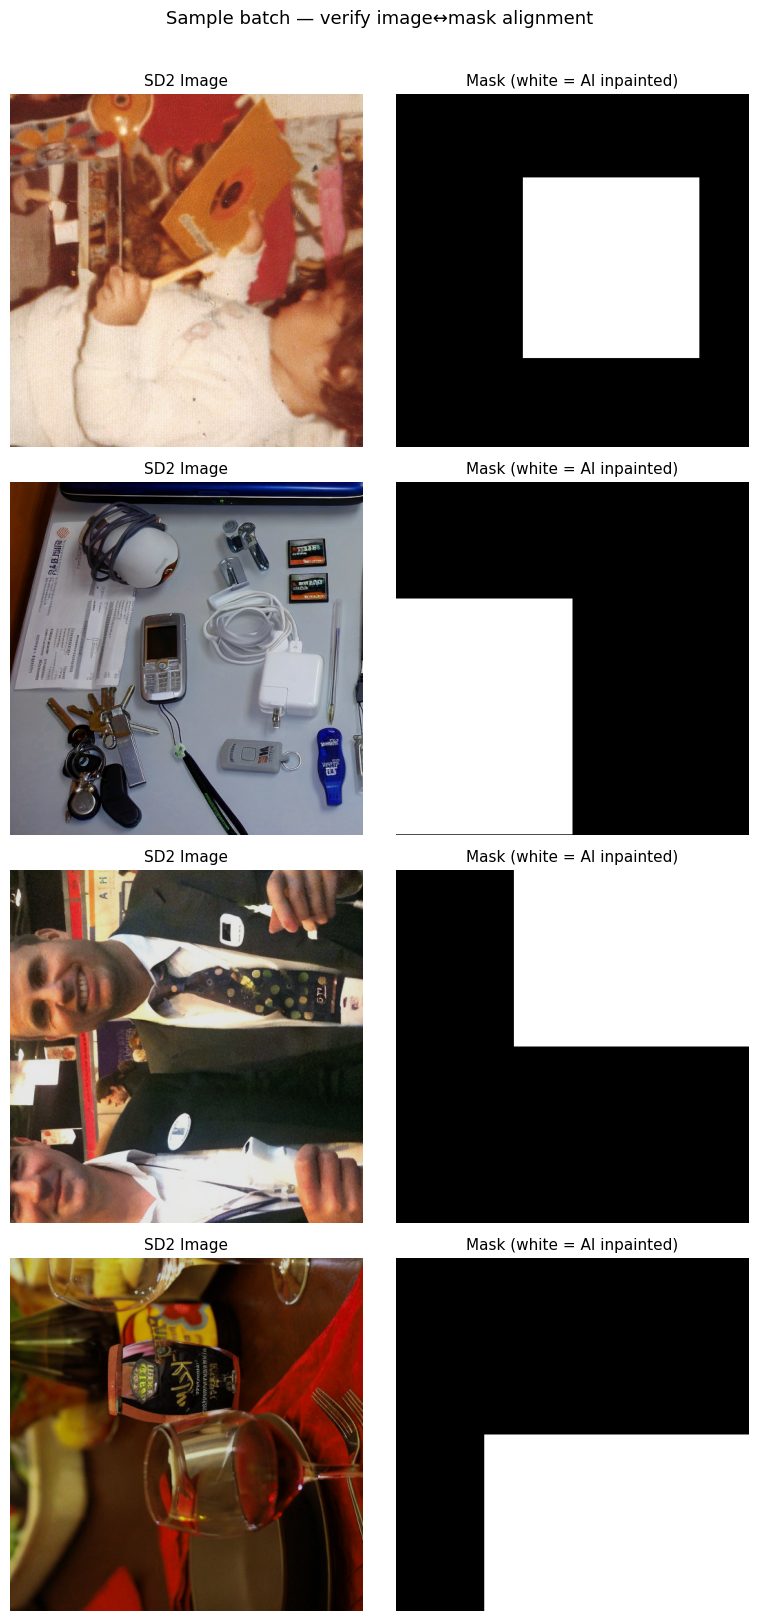

Image batch shape: torch.Size([32, 3, 512, 512])   Mask batch shape: torch.Size([32, 1, 512, 512])
Mask unique values: [0.0, 1.0]


In [20]:
def unnormalize(t):
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD ).view(3,1,1)
    return (t * std + mean).clamp(0, 1)


imgs, masks = next(iter(train_loader))
n_show = min(4, len(imgs))

fig, axes = plt.subplots(n_show, 2, figsize=(8, n_show * 4))
for i in range(n_show):
    img_disp  = unnormalize(imgs[i]).permute(1, 2, 0).numpy()
    mask_disp = masks[i].squeeze().numpy()

    axes[i, 0].imshow(img_disp)
    axes[i, 0].set_title('SD2 Image', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask_disp, cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title('Mask (white = AI inpainted)', fontsize=11)
    axes[i, 1].axis('off')

plt.suptitle('Sample batch — verify image↔mask alignment', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Image batch shape: {imgs.shape}   Mask batch shape: {masks.shape}")
print(f"Mask unique values: {masks.unique().tolist()}")

In [27]:
def build_model(config):
    model = smp.DeepLabV3Plus(
        encoder_name    = config['encoder'],          # 'resnet50' or 'resnet101'
        encoder_weights = config['encoder_weights'],  # ImageNet pretrained
        in_channels     = 3,
        classes         = config['num_classes'],      # 1 for binary segmentation
        activation      = None,                       # raw logits; we apply sigmoid in loss/metrics
    )

    dropout_p = config.get('decoder_dropout', 0.3)
    if dropout_p > 0:
        model.decoder.block = nn.Sequential(
            nn.Dropout2d(p=dropout_p),
            model.decoder.block2,
        )


    return model


model = build_model(CONFIG).to(DEVICE)

# Count params
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")

# Quick forward-pass smoke test
with torch.no_grad():
    dummy = torch.randn(2, 3, CONFIG['image_size'], CONFIG['image_size']).to(DEVICE)
    out   = model(dummy)
    print(f"Output shape     : {out.shape}  (expected [2, 1, {CONFIG['image_size']}, {CONFIG['image_size']}])")

Total params     : 26,677,585
Trainable params : 26,677,585
Output shape     : torch.Size([2, 1, 512, 512])  (expected [2, 1, 512, 512])


In [28]:
#
# Why NOT add explicit L1/L2 regularisation here?
# weight_decay in AdamW already does this correctly and more efficiently.
# Adding it to the loss on top of AdamW would double-count it and make the
# effective lambda impossible to reason about.
#
# What IS improved here:
#
#   1. Per-image Dice instead of global Dice
#      The original flattened the entire batch into one vector, so a large easy
#      background region in one image could dominate the gradient and let the
#      model be sloppy on boundary pixels.  Computing Dice per image then
#      averaging means every image contributes equally regardless of size.
#
#   2. Optional Focal loss term (gamma controls it; set to 0.0 to disable)
#      Focal loss down-weights easy background pixels (where the model is
#      already very confident) and concentrates the gradient on the hard
#      boundary pixels where the model is uncertain.  This is especially
#      useful for manipulation detection where the boundary between real and
#      fake is the hardest part to learn.
#      gamma=0  => standard BCE (Focal reduces to BCE when gamma=0)
#      gamma=2  => standard Focal (good starting point)
#      Controlled by CONFIG['focal_gamma']; default 2.0.
 
class CombinedLoss(nn.Module):
    """
    Loss = alpha * BCE(pos_weight) + beta * Focal + (1-alpha-beta) * Dice(per-image)
 
    CONFIG knobs:
        pos_weight   (float, default 3.0) : BCE class-imbalance weight
        loss_alpha   (float, default 0.4) : weight on BCE term
        loss_beta    (float, default 0.2) : weight on Focal term (0 = disable)
        focal_gamma  (float, default 2.0) : focusing exponent (0 = plain BCE)
 
    The three weights must sum to <= 1.0; the remainder goes to Dice.
    """
 
    def __init__(self, pos_weight: float = 3.0,
                 alpha: float = 0.4,
                 beta:  float = 0.2,
                 focal_gamma: float = 2.0):
        super().__init__()
        self.bce         = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
        self.alpha       = alpha          # BCE weight
        self.beta        = beta           # Focal weight
        self.gamma       = focal_gamma    # Focal focusing exponent
        self.dice_weight = 1.0 - alpha - beta   # remainder goes to Dice
 
    # --- per-image Dice (averages over the batch dimension) ---
    def _dice(self, logits, targets, smooth=1.0):
        # logits/targets shape: [B, 1, H, W]
        # Compute separately for each image, then average.
        # This prevents large easy images from dominating the gradient.
        B = logits.shape[0]
        probs   = torch.sigmoid(logits).view(B, -1)   # [B, H*W]
        targets = targets.view(B, -1)                 # [B, H*W]
        inter   = (probs * targets).sum(dim=1)        # [B]
        union   = probs.sum(dim=1) + targets.sum(dim=1)
        dice_per_img = 1.0 - (2.0 * inter + smooth) / (union + smooth)
        return dice_per_img.mean()
 
    # --- Focal loss (image-level, same idea) ---
    def _focal(self, logits, targets):
        if self.gamma == 0 or self.beta == 0:
            return torch.tensor(0.0, device=logits.device)
        # p_t = sigmoid probability of the TRUE class
        probs  = torch.sigmoid(logits)
        p_t    = probs * targets + (1 - probs) * (1 - targets)
        # (1 - p_t)^gamma down-weights easy pixels
        focal_weight = (1.0 - p_t) ** self.gamma
        bce_elem     = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        return (focal_weight * bce_elem).mean()
 
    def forward(self, logits, targets):
        bce_val   = self.bce(logits, targets)
        focal_val = self._focal(logits, targets)
        dice_val  = self._dice(logits, targets)
        return (self.alpha       * bce_val
              + self.beta        * focal_val
              + self.dice_weight * dice_val)

criterion = CombinedLoss(pos_weight=CONFIG['pos_weight']).to(DEVICE)
print("Loss function ready.")

Loss function ready.


In [29]:
def compute_metrics(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5):
    """
    Compute pixel-level binary segmentation metrics.
    Inputs:
        logits  : raw model output [B, 1, H, W]
        targets : float masks      [B, 1, H, W] with values in {0, 1}
    Returns dict with keys: iou, dice, precision, recall, f1
    """
    preds = (torch.sigmoid(logits) > threshold).float()
    preds   = preds.view(-1)
    targets = targets.view(-1)

    TP = (preds * targets).sum().item()
    FP = (preds * (1 - targets)).sum().item()
    FN = ((1 - preds) * targets).sum().item()
    TN = ((1 - preds) * (1 - targets)).sum().item()

    smooth = 1e-6
    iou       = TP / (TP + FP + FN + smooth)
    dice      = (2 * TP) / (2 * TP + FP + FN + smooth)
    precision = TP / (TP + FP + smooth)
    recall    = TP / (TP + FN + smooth)
    f1        = (2 * precision * recall) / (precision + recall + smooth)

    return dict(iou=iou, dice=dice, precision=precision, recall=recall, f1=f1)


print("Metrics function ready.")

Metrics function ready.


In [30]:
# Differential LR: lower lr for pretrained encoder, higher for decoder/head
encoder_params = list(model.encoder.parameters())
decoder_params = (list(model.decoder.parameters()) +
                  list(model.segmentation_head.parameters()))

optimizer = optim.AdamW(
    [
        {'params': encoder_params, 'lr': CONFIG['lr'] * 0.1},   # 1e-5
        {'params': decoder_params, 'lr': CONFIG['lr']},         # 1e-4
    ],
    weight_decay=CONFIG['weight_decay'],
)

# Cosine annealing with warm restarts
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['epochs'], eta_min=1e-6
)

scaler = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])

print(f"Encoder LR: {CONFIG['lr'] * 0.1:.2e}  |  Decoder LR: {CONFIG['lr']:.2e}")

Encoder LR: 1.00e-05  |  Decoder LR: 1.00e-04


/tmp/ipykernel_57295/2192186009.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])


In [31]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0.0
    all_metrics = dict(iou=0, dice=0, precision=0, recall=0, f1=0)

    pbar = tqdm(loader, desc='Train', leave=False)
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            logits = model(images)
            loss   = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        m = compute_metrics(logits.detach(), masks.detach())
        for k in all_metrics:
            all_metrics[k] += m[k]

        pbar.set_postfix(loss=f'{loss.item():.4f}', iou=f'{m["iou"]:.3f}')

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in all_metrics.items()}


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_metrics = dict(iou=0, dice=0, precision=0, recall=0, f1=0)

    pbar = tqdm(loader, desc='Eval', leave=False)
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)

        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            logits = model(images)
            loss   = criterion(logits, masks)

        total_loss += loss.item()
        m = compute_metrics(logits, masks)
        for k in all_metrics:
            all_metrics[k] += m[k]

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in all_metrics.items()}


print("Training and evaluation functions ready.")

Training and evaluation functions ready.


In [ ]:
os.makedirs(CONFIG['save_dir'], exist_ok=True)

history = {'train_loss': [], 'val_loss': [],
           'train_iou':  [], 'val_iou':  [],
           'train_dice': [], 'val_dice': []}

best_val_iou  = 0.0
best_epoch    = 0
best_metrics  = {}

print(f"Starting DeepLabV3+ fine-tuning for {CONFIG['epochs']} epochs...\n")

for epoch in range(1, CONFIG['epochs'] + 1):
    train_loss, train_m = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
    val_loss,   val_m   = evaluate       (model, val_loader,   criterion, DEVICE)
    scheduler.step()

    # --- record history ---
    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_iou' ].append(train_m['iou'])
    history['val_iou'   ].append(val_m['iou'])
    history['train_dice'].append(train_m['dice'])
    history['val_dice'  ].append(val_m['dice'])

    print(f"Epoch {epoch:02d}/{CONFIG['epochs']}  "
          f"| Train  loss={train_loss:.4f}  IoU={train_m['iou']:.4f}  Dice={train_m['dice']:.4f}"
          f"  |  Val  loss={val_loss:.4f}  IoU={val_m['iou']:.4f}  Dice={val_m['dice']:.4f}  "
          f"P={val_m['precision']:.3f}  R={val_m['recall']:.3f}")

    # --- save best checkpoint ---
    if val_m['iou'] > best_val_iou:
        best_val_iou = val_m['iou']
        best_epoch   = epoch
        best_metrics = {'epoch': epoch, **{f'val_{k}': v for k, v in val_m.items()},
                        'val_loss': val_loss}
        ckpt_path = os.path.join(CONFIG['save_dir'], 'best_model.pth')
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_iou': best_val_iou,
                    'config': CONFIG},
                   ckpt_path)
        print(f"  ✓ Saved best checkpoint  (val IoU={best_val_iou:.4f})")

# Save final checkpoint
torch.save({'epoch': CONFIG['epochs'],
            'model_state_dict': model.state_dict(),
            'config': CONFIG},
           os.path.join(CONFIG['save_dir'], 'final_model.pth'))

print(f"\nTraining complete. Best Val IoU = {best_val_iou:.4f} at epoch {best_epoch}.")

Starting DeepLabV3+ fine-tuning for 30 epochs...



Train:   0%|          | 0/458 [00:00<?, ?it/s]

/tmp/ipykernel_57295/3484827423.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):


Eval:   0%|          | 0/64 [00:00<?, ?it/s]

/tmp/ipykernel_57295/3484827423.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):


...

Train:   0%|          | 0/458 [00:00<?, ?it/s]

Eval:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 03/30  | Train  loss=0.2713  IoU=0.8246  Dice=0.9033  |  Val  loss=0.3266  IoU=0.7475  Dice=0.8315  P=0.798  R=0.875


Train:   0%|          | 0/458 [00:00<?, ?it/s]

Eval:   0%|          | 0/64 [00:00<?, ?it/s]

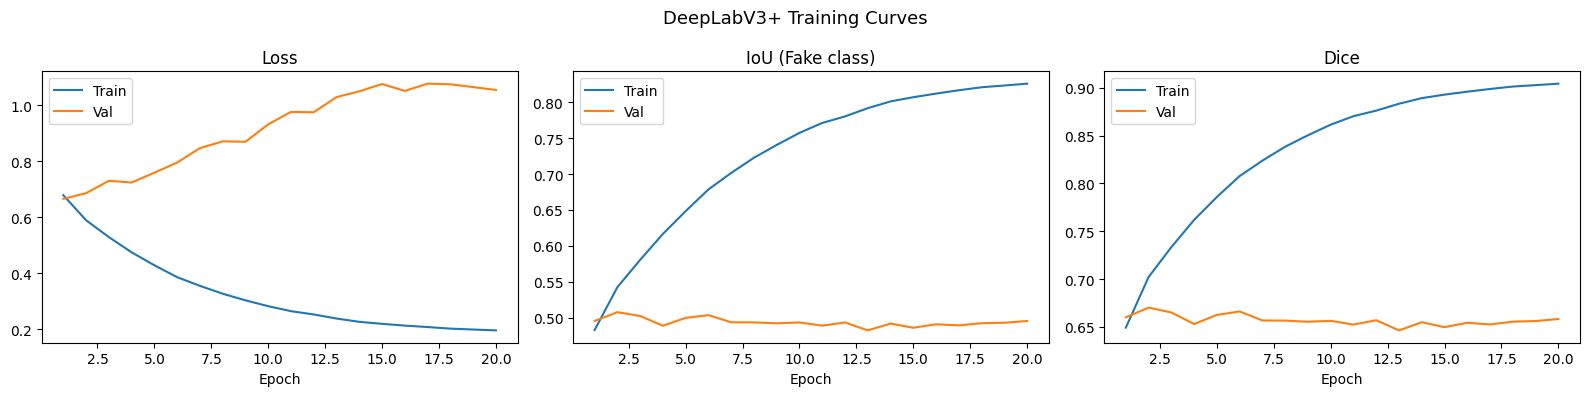

In [13]:
epochs_x = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_x, history['train_loss'], label='Train')
axes[0].plot(epochs_x, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs_x, history['train_iou'], label='Train')
axes[1].plot(epochs_x, history['val_iou'],   label='Val')
axes[1].set_title('IoU (Fake class)'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(epochs_x, history['train_dice'], label='Train')
axes[2].plot(epochs_x, history['val_dice'],   label='Val')
axes[2].set_title('Dice'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.suptitle('DeepLabV3+ Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], 'training_curves.png'), dpi=150)
plt.show()

In [14]:
# Load best checkpoint for test evaluation
ckpt = torch.load(os.path.join(CONFIG['save_dir'], 'best_model.pth'),
                  map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']} (val IoU={ckpt['val_iou']:.4f})")

test_loss, test_m = evaluate(model, test_loader, criterion, DEVICE)

print("\n" + "="*55)
print("FINAL TEST RESULTS")
print("="*55)
print(f"  Loss      : {test_loss:.4f}")
print(f"  IoU       : {test_m['iou']:.4f}")
print(f"  Dice      : {test_m['dice']:.4f}")
print(f"  Precision : {test_m['precision']:.4f}")
print(f"  Recall    : {test_m['recall']:.4f}")
print(f"  F1        : {test_m['f1']:.4f}")
print("="*55)

# Save metrics JSON
all_metrics = {
    'best_val': best_metrics,
    'test': {'loss': test_loss, **{k: v for k, v in test_m.items()}},
    'config': CONFIG,
}
metrics_path = os.path.join(CONFIG['save_dir'], 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(all_metrics, f, indent=4)
print(f"\nMetrics saved to {metrics_path}")

Loaded best checkpoint from epoch 2 (val IoU=0.5076)


/tmp/ipykernel_35637/1102291958.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(CONFIG['save_dir'], 'best_deeplabv3plus.pth'),


Eval:   0%|          | 0/129 [00:00<?, ?it/s]

/tmp/ipykernel_35637/3484827423.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):



FINAL TEST RESULTS
  Loss      : 0.6790
  IoU       : 0.5075
  Dice      : 0.6704
  Precision : 0.5771
  Recall    : 0.8085
  F1        : 0.6704

Metrics saved to ./checkpoints_deeplabv3plus/metrics.json


/tmp/ipykernel_35637/1562064791.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):


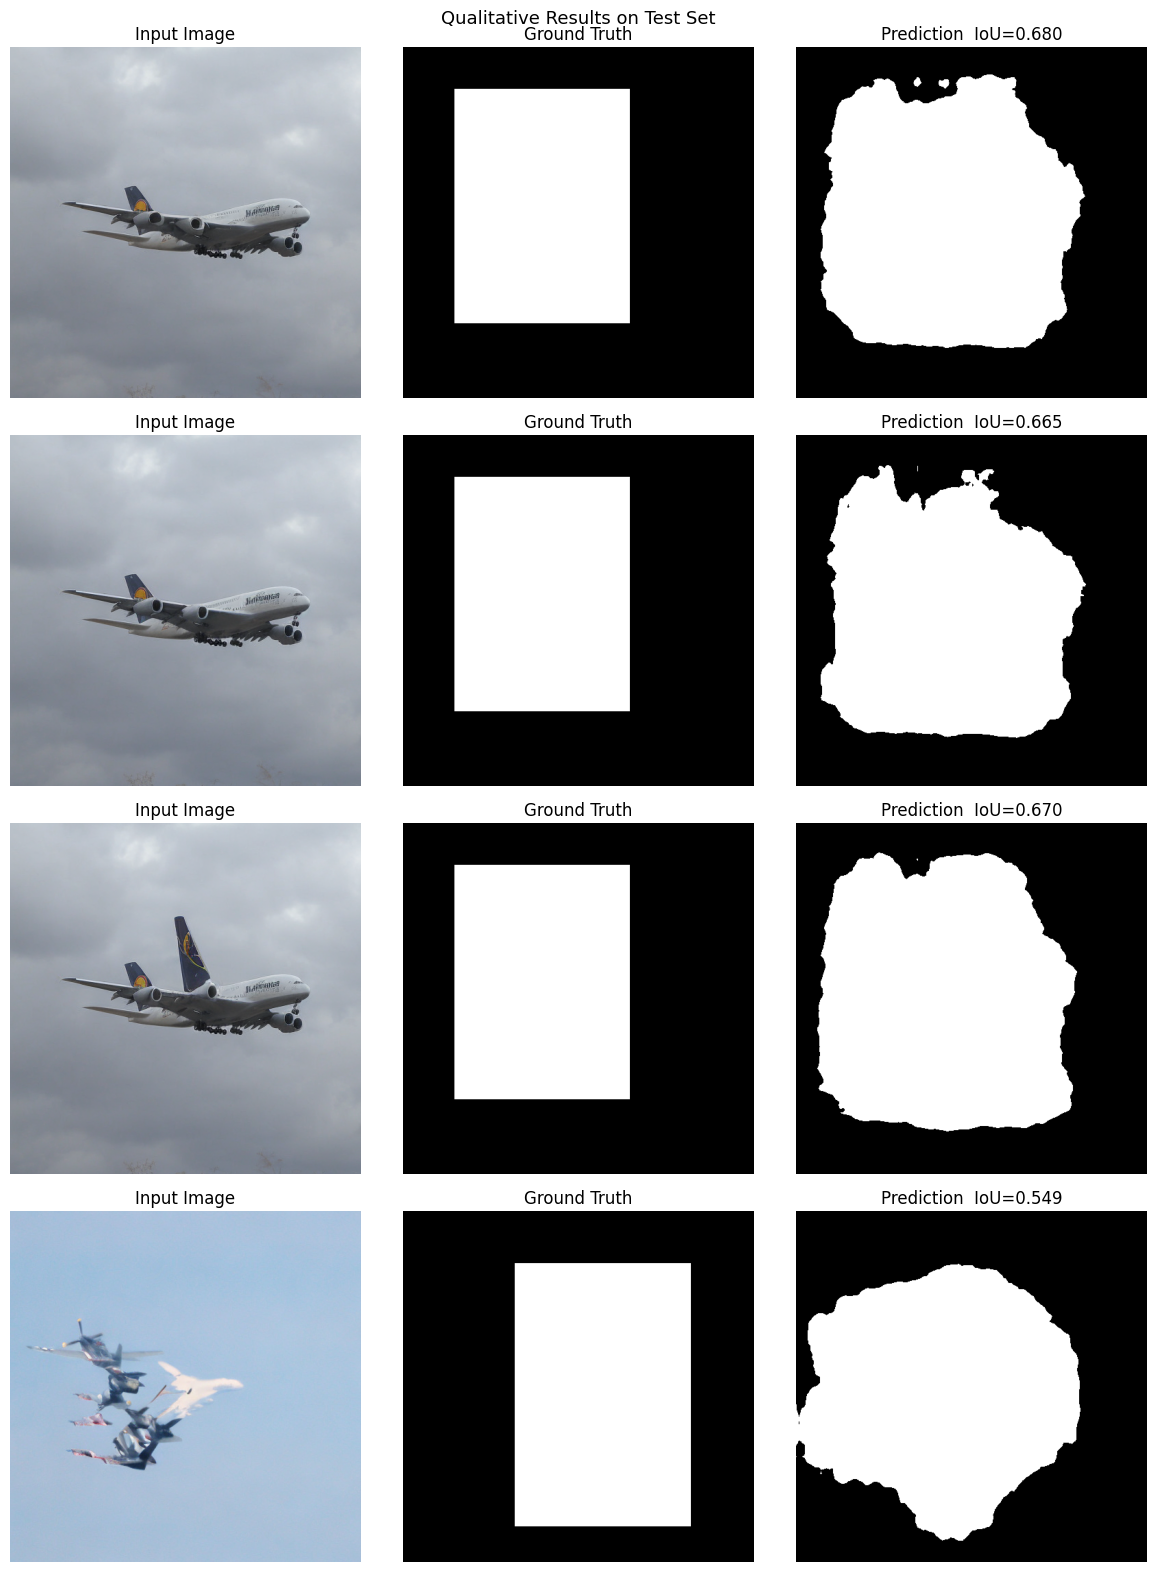

In [15]:
def visualise_predictions(model, loader, device, n_samples=4, threshold=0.5):
    model.eval()
    images, masks = next(iter(loader))
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            logits = model(images)
    preds = (torch.sigmoid(logits) > threshold).float()

    n = min(n_samples, len(images))
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))
    cols = ['Input Image', 'Ground Truth', 'Prediction']

    for i in range(n):
        img_disp  = unnormalize(images[i].cpu()).permute(1, 2, 0).numpy()
        gt_disp   = masks[i].cpu().squeeze().numpy()
        pred_disp = preds[i].cpu().squeeze().numpy()

        iou = compute_metrics(logits[i:i+1].cpu(), masks[i:i+1].cpu())['iou']

        axes[i, 0].imshow(img_disp);                    axes[i, 0].set_title(cols[0])
        axes[i, 1].imshow(gt_disp,   cmap='gray', vmin=0, vmax=1); axes[i, 1].set_title(cols[1])
        axes[i, 2].imshow(pred_disp, cmap='gray', vmin=0, vmax=1); axes[i, 2].set_title(f'{cols[2]}  IoU={iou:.3f}')

        for ax in axes[i]:
            ax.axis('off')

    plt.suptitle('Qualitative Results on Test Set', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['save_dir'], 'qualitative_results.png'), dpi=150)
    plt.show()


visualise_predictions(model, test_loader, DEVICE, n_samples=4)

/tmp/ipykernel_35637/1478853748.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):


Best threshold: 0.55  →  IoU=0.5074  Dice=0.6732  F1=0.6732


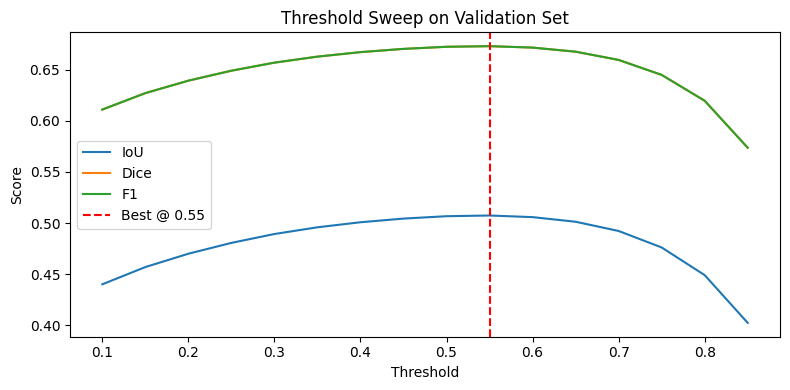


Use threshold=0.55 for final test inference.


In [16]:
@torch.no_grad()
def threshold_sweep(model, loader, device, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.1, 0.9, 0.05)

    model.eval()
    all_logits, all_masks = [], []

    for images, masks in tqdm(loader, desc='Collecting logits'):
        images = images.to(device)
        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            logits = model(images)
        all_logits.append(logits.cpu())
        all_masks.append(masks)

    all_logits = torch.cat(all_logits)
    all_masks  = torch.cat(all_masks)

    results = []
    for t in thresholds:
        m = compute_metrics(all_logits, all_masks, threshold=t)
        results.append((t, m['iou'], m['dice'], m['f1']))

    best = max(results, key=lambda x: x[1])
    print(f"Best threshold: {best[0]:.2f}  →  IoU={best[1]:.4f}  Dice={best[2]:.4f}  F1={best[3]:.4f}")

    ts, ious, dices, f1s = zip(*results)
    plt.figure(figsize=(8, 4))
    plt.plot(ts, ious,  label='IoU')
    plt.plot(ts, dices, label='Dice')
    plt.plot(ts, f1s,   label='F1')
    plt.axvline(best[0], color='red', linestyle='--', label=f'Best @ {best[0]:.2f}')
    plt.xlabel('Threshold'); plt.ylabel('Score')
    plt.title('Threshold Sweep on Validation Set')
    plt.legend(); plt.tight_layout(); plt.show()

    return best[0]


best_threshold = threshold_sweep(model, val_loader, DEVICE)
print(f"\nUse threshold={best_threshold:.2f} for final test inference.")

/tmp/ipykernel_35637/2436816473.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):


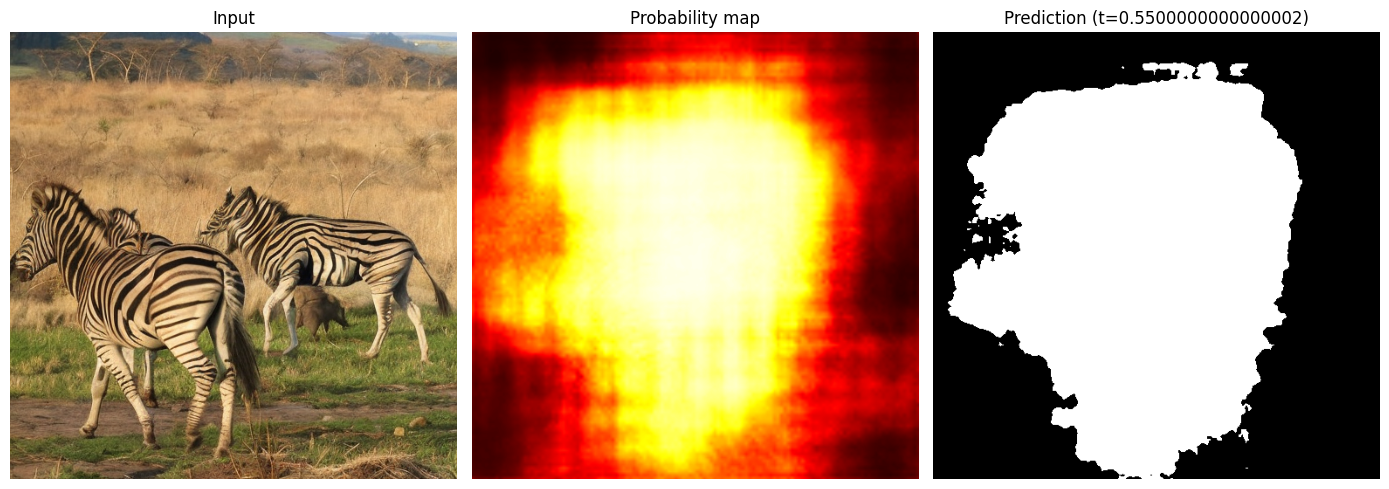

array([[0.09301681, 0.08904109, 0.08521935, ..., 0.11977735, 0.1442451 ,
        0.17272931],
       [0.08518152, 0.08128509, 0.07755177, ..., 0.11471564, 0.13461575,
        0.15735364],
       [0.07794949, 0.07414967, 0.07052092, ..., 0.10984115, 0.12553489,
        0.14310989],
       ...,
       [0.13821663, 0.13401362, 0.12991914, ..., 0.13659523, 0.1455632 ,
        0.15501395],
       [0.16350554, 0.15519556, 0.14723356, ..., 0.14653187, 0.15606607,
        0.16609962],
       [0.19238758, 0.17903256, 0.16641358, ..., 0.15705949, 0.16717815,
        0.17781086]], shape=(512, 512), dtype=float32)

In [17]:
def predict_single(model, image_path: str, device, threshold: float = 0.5,
                   image_size: int = 512):
    """
    Run inference on a single image file and display the prediction.
    Returns the probability map as a numpy array.
    """
    model.eval()

    img = Image.open(image_path).convert('RGB')
    orig_size = img.size  # (W, H)

    img_r = img.resize((image_size, image_size), Image.BILINEAR)
    t = TF.to_tensor(img_r)
    t = TF.normalize(t, mean=MEAN, std=STD).unsqueeze(0).to(device)

    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            logit = model(t)
    prob = torch.sigmoid(logit).squeeze().cpu().numpy()
    pred = (prob > threshold).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    axes[0].imshow(img);                         axes[0].set_title('Input')
    axes[1].imshow(prob, cmap='hot', vmin=0, vmax=1); axes[1].set_title('Probability map')
    axes[2].imshow(pred, cmap='gray', vmin=0, vmax=1);axes[2].set_title(f'Prediction (t={threshold})')
    for ax in axes: ax.axis('off')
    plt.tight_layout(); plt.show()

    return prob


# Example usage — replace with any image path
predict_single(model, DATA_DIR / 'sd2-fr/testing/zebra/110211_mask_random.png_sd2-512_0.png',
               DEVICE, threshold=best_threshold)